# SFT Results

Run all cells to generate paper figures and full results for all dataset/task combinations.

In [30]:
import json
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

In [31]:
# ============================================
# Configuration
# ============================================
SCRATCH_DIR = "/work/hdd/bfwm/phu1/Project"
out_dir = f"{SCRATCH_DIR}/Gradient-Streaming/SFT"
lr_config_path = "./train/lr/config.json"
save_dir = './figures'
os.makedirs(save_dir, exist_ok=True)

model = 'Llama-3.2-1B'

# All dataset+task combinations to analyze
DATASETS = [
    {'train': 'alpaca', 'task': 'samsum', 'subject': '', 'percentage': 0.4},
    {'train': 'tulu3',  'task': 'tydiqa', 'subject': '', 'percentage': 0.01},
]

# Shared hyperparameters
SHARED_CONFIG = {
    'batch_size': 8,
    'n_val': 32,
    'lr_full_fallback': '5e-05',
    'lr_lora_fallback': '2e-04',
}

# Methods: "{Method}-{Finetuning}"
ALL_METHODS = [
    'Standard-Full', 'Standard-LoRA', 'Standard-MeSO',
    'Layerwise-Full', 'Layerwise-LoRA', 'Layerwise-MeSO',
    'Subset-Full', 'Subset-LoRA', 'Subset-MeSO',
]

# Paper figure grouping: one plot per finetuning type
FINETUNING_GROUPS = {
    'Full': ['Standard-Full', 'Subset-Full', 'Layerwise-Full'],
    'LoRA': ['Standard-LoRA', 'Subset-LoRA', 'Layerwise-LoRA'],
    'MeSO': ['Standard-MeSO', 'Subset-MeSO', 'Layerwise-MeSO'],
}

LEGEND_NAMES = {
    'Standard-Full': 'Standard', 'Standard-LoRA': 'Standard', 'Standard-MeSO': 'Standard',
    'Layerwise-Full': 'Layer-wise', 'Layerwise-LoRA': 'Layer-wise', 'Layerwise-MeSO': 'Layer-wise',
    'Subset-Full': 'Subset', 'Subset-LoRA': 'Subset', 'Subset-MeSO': 'Subset',
}

METHOD_COLORS = {
    'Standard-Full': 'black', 'Standard-LoRA': 'black', 'Standard-MeSO': 'black',
    'Layerwise-Full': 'red', 'Layerwise-LoRA': 'red', 'Layerwise-MeSO': 'red',
    'Subset-Full': 'green', 'Subset-LoRA': 'green', 'Subset-MeSO': 'green',
}

# Task-specific evaluation metrics
TASK_METRICS = {
    'samsum': {
        'result_file': 'samsum_results.json',
        'metrics': ['rouge1', 'rouge2', 'rougeL'],
        'display_names': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
        'primary_metric': 'rougeL',
        'format': lambda x: f"{x:.3f}" if x is not None else 'N/A',
    },
    'tydiqa': {
        'result_file': 'tydiqa_results.json',
        'metrics': ['f1_score', 'exact_match'],
        'display_names': ['F1 Score', 'Exact Match'],
        'primary_metric': 'f1_score',
        'format': lambda x: f"{x:.2f}" if x is not None else 'N/A',
    },
}

# Load LR configuration
lr_config = {}
if Path(lr_config_path).exists():
    with open(lr_config_path, 'r') as f:
        lr_config = json.load(f)
    print(f"Loaded LR config from {lr_config_path}")

print(f"Datasets: {[(d['train'], d['task']) for d in DATASETS]}")
print(f"Methods: {len(ALL_METHODS)}")

Loaded LR config from ./train/lr/config.json
Datasets: [('alpaca', 'samsum'), ('tulu3', 'tydiqa')]
Methods: 9


## Helper Functions & Load All Data

In [32]:
# ============================================
# Helper functions (parameterized, no globals)
# ============================================

def _finetuning_type(name):
    return name.split('-', 1)[1]

def _config_key(train_dataset, task, subject=''):
    if task in ['mmlu', 'bbh'] and subject:
        return f"{train_dataset}_{task}_{subject}"
    return f"{train_dataset}_{task}"

def _lookup_lr(method_name, train_dataset, task, subject=''):
    key = _config_key(train_dataset, task, subject)
    if lr_config and key in lr_config:
        entry = lr_config[key].get(method_name, {})
        lr_val = entry.get('lr')
        if lr_val is not None:
            return f'{lr_val:.0e}' if lr_val < 0.001 else f'{lr_val}'
    ft = _finetuning_type(method_name)
    return SHARED_CONFIG['lr_lora_fallback'] if ft == 'LoRA' else SHARED_CONFIG['lr_full_fallback']

def _dir_name(method_name, seed, ds):
    """Build experiment directory name."""
    lr = _lookup_lr(method_name, ds['train'], ds['task'], ds.get('subject', ''))
    task_str = f"{ds['task']}_{ds['subject']}" if ds['task'] in ['mmlu', 'bbh'] and ds.get('subject') else ds['task']
    cfg = SHARED_CONFIG
    return (f"{ds['train']}_{task_str}-{model}-{method_name}"
            f"-p{ds['percentage']}-lr{lr}-b{cfg['batch_size']}-v{cfg['n_val']}-s{seed}")

def _discover_seeds(method_name, ds):
    pattern = _dir_name(method_name, '*', ds)
    seeds = []
    for p in glob(f"{out_dir}/{pattern}"):
        m = re.search(r'-s(\d+)$', Path(p).name)
        if m:
            seeds.append(int(m.group(1)))
    return sorted(seeds)

def _load_eval_results(path):
    with open(path, 'r') as f:
        data = json.load(f)
    steps = [item['step'] for item in data]
    val_ppl = [item['val_perplexity'] for item in data]
    eval_ppl = [item['eval_perplexity'] for item in data]
    wt = [item.get('wall_time') for item in data]
    return {
        'steps': np.array(steps),
        'val_perplexity': np.array(val_ppl),
        'eval_perplexity': np.array(eval_ppl),
        'wall_time': np.array(wt) if all(t is not None for t in wt) else None,
    }

def load_method_results(method_name, ds):
    """Load and aggregate results across all seeds for a method + dataset."""
    seeds = _discover_seeds(method_name, ds)
    if not seeds:
        return None
    all_res, valid_seeds = [], []
    for seed in seeds:
        path = f"{out_dir}/{_dir_name(method_name, seed, ds)}/evaluation_results.json"
        if Path(path).exists():
            all_res.append(_load_eval_results(path))
            valid_seeds.append(seed)
    if not all_res:
        return None
    min_len = min(len(r['steps']) for r in all_res)
    steps = all_res[0]['steps'][:min_len]
    val_ppl = np.stack([r['val_perplexity'][:min_len] for r in all_res])
    eval_ppl = np.stack([r['eval_perplexity'][:min_len] for r in all_res])
    wts = [r['wall_time'] for r in all_res if r['wall_time'] is not None]
    if len(wts) == len(all_res):
        wt = np.stack([w[:min_len] for w in wts])
        wt_mean, wt_std = np.mean(wt, axis=0), np.std(wt, axis=0)
    else:
        wt_mean = wt_std = None
    return {
        'steps': steps,
        'val_perplexity_mean': np.mean(val_ppl, axis=0), 'val_perplexity_std': np.std(val_ppl, axis=0),
        'eval_perplexity_mean': np.mean(eval_ppl, axis=0), 'eval_perplexity_std': np.std(eval_ppl, axis=0),
        'wall_time_mean': wt_mean, 'wall_time_std': wt_std,
        'n_seeds': len(valid_seeds), 'seeds': valid_seeds,
    }

def load_task_metric(method_name, ds, seeds):
    """Load task-specific eval (ROUGE, F1, etc.) across seeds."""
    task = ds['task']
    if task not in TASK_METRICS:
        return None
    result_file = TASK_METRICS[task]['result_file']
    seed_results, valid_seeds = [], []
    for seed in seeds:
        path = f"{out_dir}/{_dir_name(method_name, seed, ds)}/{result_file}"
        if Path(path).exists():
            with open(path, 'r') as f:
                seed_results.append(json.load(f))
                valid_seeds.append(seed)
    if not seed_results:
        return None
    aggregated = {'seeds': valid_seeds, 'n_seeds': len(valid_seeds)}
    for metric in TASK_METRICS[task]['metrics']:
        values = [r.get(metric) for r in seed_results if r.get(metric) is not None]
        if values:
            aggregated[f'{metric}_mean'] = np.mean(values)
            aggregated[f'{metric}_std'] = np.std(values)
        else:
            aggregated[f'{metric}_mean'] = None
            aggregated[f'{metric}_std'] = None
    return aggregated


# ============================================
# Load ALL data upfront
# ============================================
# all_results[ds_key][method_name] = {steps, eval_perplexity_mean, ...}
# all_task_results[ds_key][method_name] = {rougeL_mean, f1_score_mean, ...}

all_results = {}
all_task_results = {}

for ds in DATASETS:
    ds_key = f"{ds['train']}_{ds['task']}"
    print(f"\n{'='*60}")
    print(f"Loading: {ds_key}")
    print(f"{'='*60}")

    results = {}
    task_results = {}

    for method_name in ALL_METHODS:
        data = load_method_results(method_name, ds)
        if data:
            results[method_name] = data
            seeds = data['seeds']
            print(f"  + {method_name}: {data['n_seeds']} seeds, {len(data['steps'])} points")

            # Also load task-specific metrics
            tdata = load_task_metric(method_name, ds, seeds)
            if tdata:
                task_results[method_name] = tdata
        else:
            print(f"  - {method_name}: Not found")

    all_results[ds_key] = results
    all_task_results[ds_key] = task_results
    print(f"  Loaded {len(results)}/{len(ALL_METHODS)} training, {len(task_results)} task-specific")

print(f"\n{'='*60}")
print(f"All data loaded: {list(all_results.keys())}")
print(f"{'='*60}")


Loading: alpaca_samsum
  + Standard-Full: 5 seeds, 55 points
  + Standard-LoRA: 5 seeds, 55 points
  + Standard-MeSO: 5 seeds, 55 points
  + Layerwise-Full: 5 seeds, 55 points
  + Layerwise-LoRA: 5 seeds, 55 points
  + Layerwise-MeSO: 5 seeds, 55 points
  + Subset-Full: 5 seeds, 55 points
  + Subset-LoRA: 5 seeds, 55 points
  + Subset-MeSO: 5 seeds, 55 points
  Loaded 9/9 training, 4 task-specific

Loading: tulu3_tydiqa
  + Standard-Full: 5 seeds, 25 points
  + Standard-LoRA: 5 seeds, 25 points
  + Standard-MeSO: 5 seeds, 25 points
  + Layerwise-Full: 5 seeds, 25 points
  + Layerwise-LoRA: 5 seeds, 25 points
  + Layerwise-MeSO: 5 seeds, 25 points
  + Subset-Full: 5 seeds, 25 points
  + Subset-LoRA: 5 seeds, 25 points
  + Subset-MeSO: 5 seeds, 25 points
  Loaded 9/9 training, 2 task-specific

All data loaded: ['alpaca_samsum', 'tulu3_tydiqa']


## Paper Figures: Eval Perplexity vs Wall Time

One plot per (dataset, finetuning type). Each plot compares Standard vs Subset vs Layer-wise.


  alpaca_samsum

  [alpaca_samsum] Full: Eval Perplexity vs Wall Time
    Methods: Standard, Subset, Layer-wise
    + Standard-Full: 5 seeds, final=5.8596
    + Subset-Full: 5 seeds, final=5.4945
    + Layerwise-Full: 5 seeds, final=5.1356
    -> Saved: ./figures/alpaca_samsum_Full.pdf


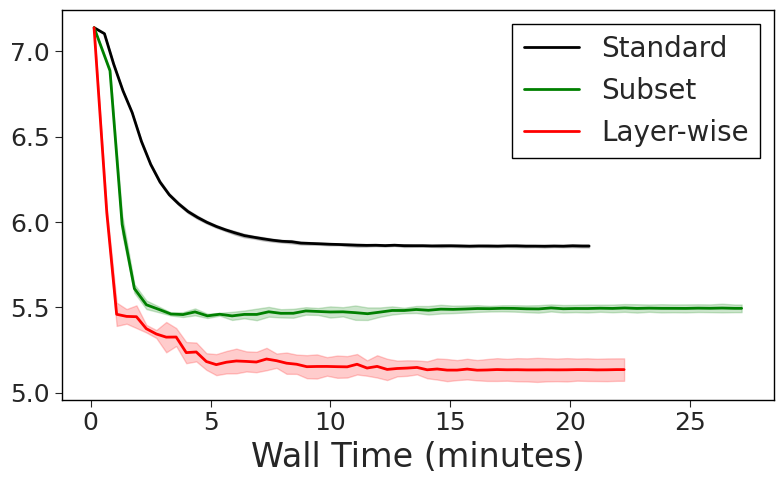


  [alpaca_samsum] LoRA: Eval Perplexity vs Wall Time
    Methods: Standard, Subset, Layer-wise
    + Standard-LoRA: 5 seeds, final=5.6811
    + Subset-LoRA: 5 seeds, final=5.5163
    + Layerwise-LoRA: 5 seeds, final=4.8089
    -> Saved: ./figures/alpaca_samsum_LoRA.pdf


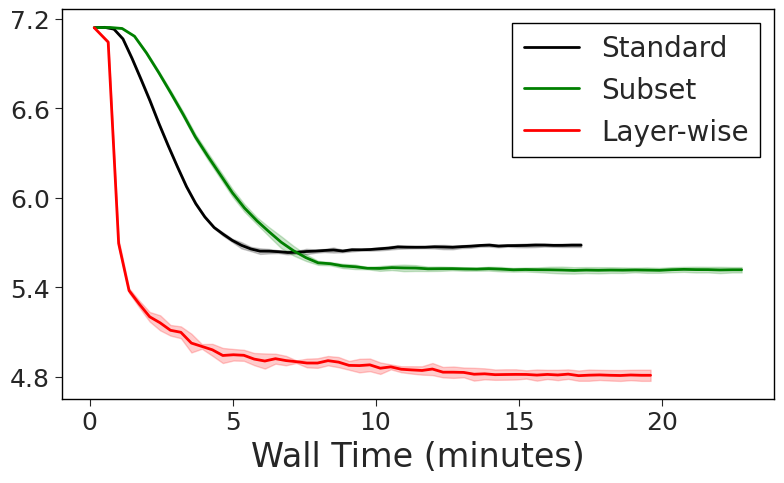


  [alpaca_samsum] MeSO: Eval Perplexity vs Wall Time
    Methods: Standard, Subset, Layer-wise
    + Standard-MeSO: 5 seeds, final=6.0067
    + Subset-MeSO: 5 seeds, final=5.5232
    + Layerwise-MeSO: 5 seeds, final=4.8676
    -> Saved: ./figures/alpaca_samsum_MeSO.pdf


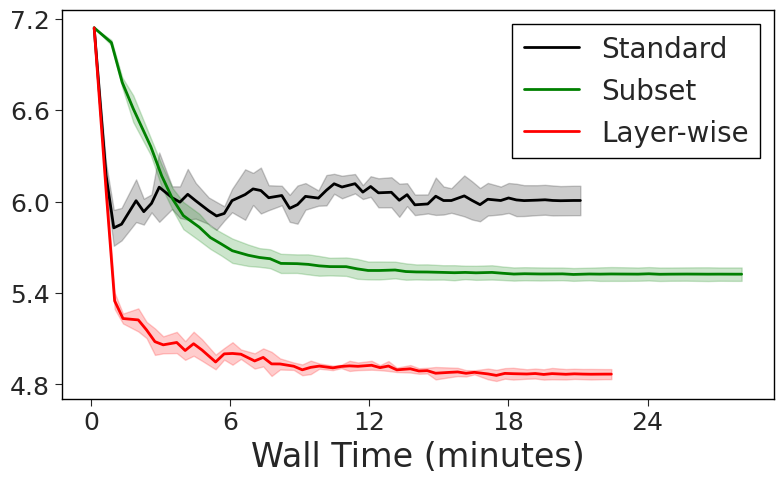


  tulu3_tydiqa

  [tulu3_tydiqa] Full: Eval Perplexity vs Wall Time
    Methods: Standard, Subset, Layer-wise
    + Standard-Full: 5 seeds, final=2.0603
    + Subset-Full: 5 seeds, final=1.7264
    + Layerwise-Full: 5 seeds, final=1.4992
    -> Saved: ./figures/tulu3_tydiqa_Full.pdf


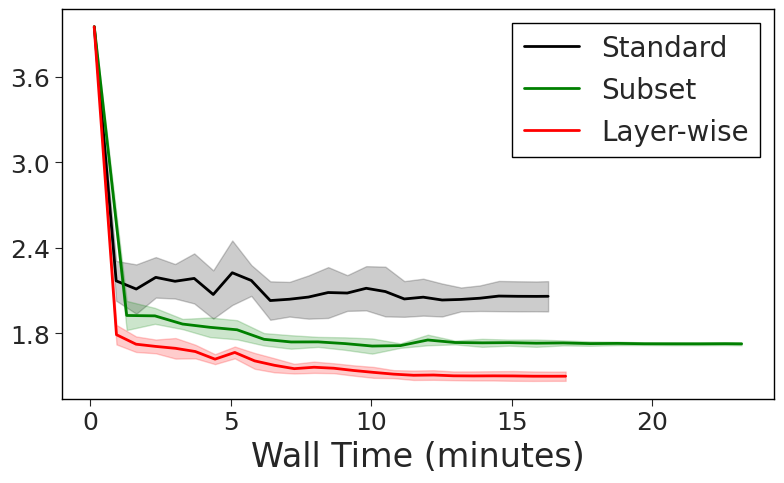


  [tulu3_tydiqa] LoRA: Eval Perplexity vs Wall Time
    Methods: Standard, Subset, Layer-wise
    + Standard-LoRA: 5 seeds, final=2.0954
    + Subset-LoRA: 5 seeds, final=1.6863
    + Layerwise-LoRA: 5 seeds, final=1.4741
    -> Saved: ./figures/tulu3_tydiqa_LoRA.pdf


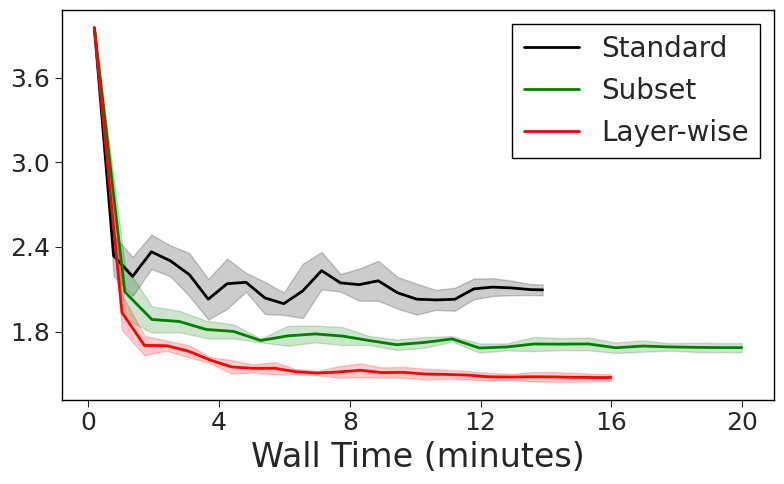


  [tulu3_tydiqa] MeSO: Eval Perplexity vs Wall Time
    Methods: Standard, Subset, Layer-wise
    + Standard-MeSO: 5 seeds, final=2.0761
    + Subset-MeSO: 5 seeds, final=1.7515
    + Layerwise-MeSO: 5 seeds, final=1.4297
    -> Saved: ./figures/tulu3_tydiqa_MeSO.pdf


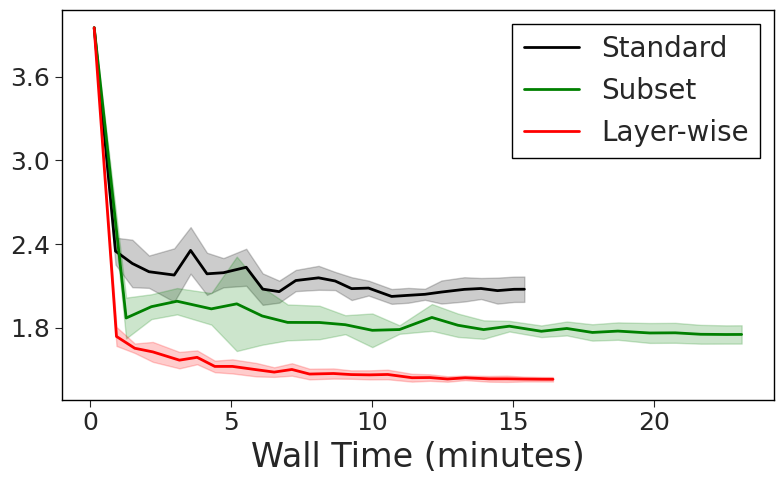

In [33]:
# Paper figures: one per (dataset, finetuning type)
# Each compares Standard vs Subset vs Layerwise on eval perplexity vs wall time

time_cutoff_minutes = None  # Set to clip x-axis

for ds in DATASETS:
    ds_key = f"{ds['train']}_{ds['task']}"
    results = all_results[ds_key]

    print(f"\n{'='*60}")
    print(f"  {ds_key}")
    print(f"{'='*60}")

    for ft_name, ft_methods in FINETUNING_GROUPS.items():
        print(f"\n  [{ds_key}] {ft_name}: Eval Perplexity vs Wall Time")
        print(f"    Methods: {', '.join(LEGEND_NAMES.get(m, m) for m in ft_methods)}")

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')

        has_data = False
        for method_name in ft_methods:
            if method_name not in results:
                print(f"    - {method_name}: no data")
                continue
            data = results[method_name]
            if data['wall_time_mean'] is None:
                print(f"    - {method_name}: no wall time")
                continue

            x = data['wall_time_mean'] / 60.0
            mean = data['eval_perplexity_mean']
            std = data['eval_perplexity_std']
            color = METHOD_COLORS.get(method_name)
            display = LEGEND_NAMES.get(method_name, method_name)

            ax.plot(x, mean, linewidth=2, label=display, color=color)
            if data['n_seeds'] > 1:
                ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)
            has_data = True
            print(f"    + {method_name}: {data['n_seeds']} seeds, final={mean[-1]:.4f}")

        ax.set_xlabel('Wall Time (minutes)', fontsize=24)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('black')
        ax.tick_params(axis='both', which='major', labelsize=18, direction='out', length=5)
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))
        if time_cutoff_minutes is not None:
            ax.set_xlim(left=0, right=time_cutoff_minutes)

        if has_data:
            legend = ax.legend(loc='upper right', fontsize=20, frameon=True,
                              edgecolor='black', fancybox=False, framealpha=1.0)
            legend.get_frame().set_facecolor('white')
        else:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', fontsize=15, color='gray')

        plt.tight_layout()
        filepath = os.path.join(save_dir, f"{ds_key}_{ft_name}.pdf")
        fig.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
        print(f"    -> Saved: {filepath}")
        plt.show()

## Results Tables: Perplexity + Task-Specific Metrics (All Datasets)

In [34]:
def _fmt(mean, std, n_seeds, fmt_fn=None):
    if mean is None:
        return 'N/A'
    if fmt_fn:
        base = fmt_fn(mean)
    else:
        base = f"{mean:.4f}"
    if n_seeds > 1 and std is not None:
        if '%' in base:
            return f"{mean*100:.1f} +/- {std*100:.1f}%"
        return f"{mean:.4f} +/- {std:.4f}" if fmt_fn is None else f"{mean:.3f} +/- {std:.3f}"
    return base


for ds in DATASETS:
    ds_key = f"{ds['train']}_{ds['task']}"
    results = all_results[ds_key]
    task_results = all_task_results[ds_key]

    # --- Perplexity table ---
    print(f"\n{'='*100}")
    print(f"Final Perplexity: {ds_key}")
    print(f"{'='*100}")
    print(f"{'Method':<25} {'Seeds':<7} {'Val PPL':<22} {'Eval PPL':<22}")
    print("-" * 100)

    for name, data in sorted(results.items(), key=lambda x: x[1]['eval_perplexity_mean'][-1]):
        n = data['n_seeds']
        val_str = _fmt(data['val_perplexity_mean'][-1], data['val_perplexity_std'][-1], n)
        eval_str = _fmt(data['eval_perplexity_mean'][-1], data['eval_perplexity_std'][-1], n)
        print(f"{name:<25} {n:<7} {val_str:<22} {eval_str:<22}")
    print("=" * 100)

    # --- Task-specific table ---
    task = ds['task']
    if task_results and task in TASK_METRICS:
        tm = TASK_METRICS[task]
        primary = tm['primary_metric']

        print(f"\n{'='*100}")
        print(f"Task Eval: {ds_key} ({task.upper()})")
        print(f"{'='*100}")
        header = f"{'Method':<25} {'Seeds':<7}"
        for dn in tm['display_names']:
            header += f" {dn:>18}"
        print(header)
        print("-" * 100)

        for name, data in sorted(task_results.items(),
                                  key=lambda x: x[1].get(f'{primary}_mean', 0) or 0, reverse=True):
            n = data['n_seeds']
            row = f"{name:<25} {n:<7}"
            for metric in tm['metrics']:
                mean = data.get(f'{metric}_mean')
                std = data.get(f'{metric}_std')
                row += f" {_fmt(mean, std, n, tm['format']):>18}"
            print(row)
        print(f"{'='*100}")
        print(f"Loaded {len(task_results)}/{len(ALL_METHODS)} task-specific results")
    else:
        print(f"\nNo task-specific results for {ds_key}. Run SFT eval.")


Final Perplexity: alpaca_samsum
Method                    Seeds   Val PPL                Eval PPL              
----------------------------------------------------------------------------------------------------
Layerwise-LoRA            5       3.9637 +/- 0.0813      4.8089 +/- 0.0374     
Layerwise-MeSO            5       3.7662 +/- 0.0243      4.8676 +/- 0.0331     
Layerwise-Full            5       4.5503 +/- 0.0542      5.1356 +/- 0.0659     
Subset-Full               5       5.3673 +/- 0.0326      5.4945 +/- 0.0225     
Subset-LoRA               5       5.3765 +/- 0.0439      5.5163 +/- 0.0180     
Subset-MeSO               5       5.4043 +/- 0.0616      5.5232 +/- 0.0440     
Standard-LoRA             5       5.6638 +/- 0.0242      5.6811 +/- 0.0122     
Standard-Full             5       6.1477 +/- 0.0092      5.8596 +/- 0.0084     
Standard-MeSO             5       6.1358 +/- 0.1371      6.0067 +/- 0.0965     

Task Eval: alpaca_samsum (SAMSUM)
Method                    Seeds